# Energy Systems Group Assignment 2026

Input data (`students/data`) comes from a 49-node European PyPSA network (2019 weather year):
the **windiest** node (DK1) is *North*, the **sunniest** node (ES0) is *South*, sampled as four
representative weeks (winter/spring/summer/autumn) at 3-hourly resolution (224 snapshots).
Costs are aligned with `costs_2050`. Solved with HiGHS.

Build a **two-node capacity expansion model** from scratch and analyse the value of transmission.
See the slides for the full problem description and graded questions.

The input data in `data/` must be read as-is — do not regenerate it.

For **every quantitative subtask** report a **quantity**, a **plot**, and a short **interpretation**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import linopy as lp
import xarray as xr
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "students" / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate students/data from the current working directory")

In [2]:
REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR  = REPO_ROOT / "students" / "data"
DT = 3.0  # hours per snapshot

tech_data = pd.read_csv(DATA_DIR / "tech_data.csv",  index_col=0)
load      = pd.read_csv(DATA_DIR / "load.csv",        index_col=0, parse_dates=True)
cf        = pd.read_csv(DATA_DIR / "capacity_factors.csv", index_col=0, parse_dates=True)

nodes      = ["north", "south"]
node_index = pd.Index(nodes, name="node")
time_index = pd.Index(load.index, name="time")
T_WINDOW   = DT * len(time_index)   # 672 h
YEAR_FRACTION = T_WINDOW / 8760

wind_cf = xr.DataArray(
    pd.DataFrame({"north": cf["wind_north"], "south": cf["wind_south"]}).to_numpy(),
    coords={"time": time_index, "node": node_index}, dims=("time","node"), name="wind_cf")
solar_cf = xr.DataArray(
    pd.DataFrame({"north": cf["solar_north"], "south": cf["solar_south"]}).to_numpy(),
    coords={"time": time_index, "node": node_index}, dims=("time","node"), name="solar_cf")
demand_da = xr.DataArray(
    load[nodes].to_numpy(),
    coords={"time": time_index, "node": node_index}, dims=("time","node"), name="demand")

tech_data

,kind,c_var_other,overnight_cost,FOM,lifetime,efficiency
component,,,,,,
Wind,power,1.623,1286467.0,15148.0,30.0,NaN
Solar,power,0.000,367867.0,9304.0,40.0,NaN
H2_electrolyser,charge_power,0.000,1257335.0,50293.0,25.0,0.6994
H2_fuel_cell,discharge_power,0.000,1068642.0,53432.0,10.0,0.5000
H2_store,energy,0.000,1604.0,0.0,100.0,NaN
Battery_inverter,power,0.000,80223.0,722.0,10.0,0.9600
Battery_store,energy,0.000,100279.0,0.0,30.0,NaN
Line,power,0.000,1544274.0,23164.0,40.0,NaN


### Input data — capacity factors and demand (4 seasonal weeks, 3-hourly)

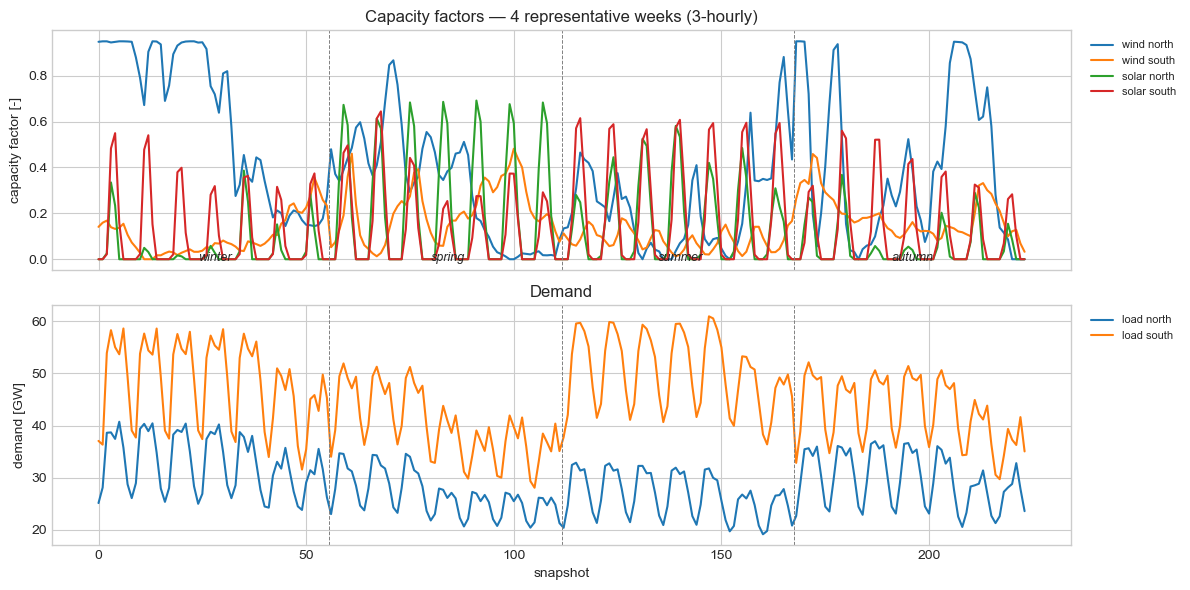

In [3]:
seasons = load["season"].values
bounds  = np.where(seasons[:-1] != seasons[1:])[0] + 0.5
x = np.arange(len(load))

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(x, cf["wind_north"],  label="wind north")
ax[0].plot(x, cf["wind_south"],  label="wind south")
ax[0].plot(x, cf["solar_north"], label="solar north")
ax[0].plot(x, cf["solar_south"], label="solar south")
ax[0].set_ylabel("capacity factor [-]")
ax[0].set_title("Capacity factors — 4 representative weeks (3-hourly)")
ax[0].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

ax[1].plot(x, load["north"]/1e3, label="load north")
ax[1].plot(x, load["south"]/1e3, label="load south")
ax[1].set_ylabel("demand [GW]")
ax[1].set_xlabel("snapshot")
ax[1].set_title("Demand")
ax[1].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

for b in bounds:
    for a_ in ax: a_.axvline(b, color="grey", ls="--", lw=0.7)
for i, lab in enumerate(["winter", "spring", "summer", "autumn"]):
    ax[0].text(28 + 56*i, 0.04, lab, ha="center", fontsize=9, style="italic",
               transform=ax[0].get_xaxis_transform())

plt.tight_layout()
plt.savefig("fig_inputdata.png", dpi=120, bbox_inches="tight")
plt.show()

## Task 1 — Build the model and present the primal solution (3 pts)

Build a two-node capacity expansion model from scratch.
Solve for **Scenario B** (no line, `line_cap` forced to 0) and **Scenario A** (line as a free
decision variable). All investment costs are annualised with the annuity factor at `r = 7%` and
pro-rated to the modelled window via `YEAR_FRACTION`.

### Task 1a — Annuity factor and annualised investment costs (0.5 pt)

Compute the **annuity factor $a(r,L)$** and the **annualised investment costs** for all technologies ($r = 7\%$):

$$a(r,L) = \frac{r(1+r)^L}{(1+r)^L - 1}, \qquad c_\mathrm{inv} = \mathrm{overnight} \cdot a(r,L) + \mathrm{FOM}$$

**Output:** table.

In [4]:
# TODO 1a — compute annuity factor and annualised investment costs (r = 0.07)
r = 0.07 

tech_data["annuity_factor"] = r * (1+r)**tech_data["lifetime"] / ((1+r)**tech_data["lifetime"] - 1)

tech_data["c_inv"] = tech_data["overnight_cost"] * tech_data["annuity_factor"] + tech_data["FOM"]

In [5]:
tech_data

,kind,c_var_other,overnight_cost,FOM,lifetime,efficiency,annuity_factor,c_inv
component,,,,,,,,
Wind,power,1.623,1286467.0,15148.0,30.0,NaN,0.080586,118819.748766
Solar,power,0.000,367867.0,9304.0,40.0,NaN,0.075009,36897.386890
H2_electrolyser,charge_power,0.000,1257335.0,50293.0,25.0,0.6994,0.085811,158185.566670
H2_fuel_cell,discharge_power,0.000,1068642.0,53432.0,10.0,0.5000,0.142378,205582.579270
H2_store,energy,0.000,1604.0,0.0,100.0,NaN,0.070081,112.409546
Battery_inverter,power,0.000,80223.0,722.0,10.0,0.9600,0.142378,12143.950401
Battery_store,energy,0.000,100279.0,0.0,30.0,NaN,0.080586,8081.123958
Line,power,0.000,1544274.0,23164.0,40.0,NaN,0.075009,138998.662925


### Task 1b — Dispatch in the no-line scenario (0.5 pt)

In the **no-line case**, what does the dispatch of **solar and wind** look like in each node?

**Output:** dispatch plot.

In [6]:
# TODO 1b — extract annualised cost and efficiency parameters from tech_data,
#            then implement def solve(allow_line: bool) and run mB = solve(False)
c_inv = tech_data["c_inv"]
eff_electrolyser = tech_data.loc["H2_electrolyser", "efficiency"]
eff_fuel_cell = tech_data.loc["H2_fuel_cell", "efficiency"]
eff_bat_inverter = tech_data.loc["Battery_inverter", "efficiency"]
c_var_wind = tech_data.loc["Wind", "c_var_other"]
c_var_solar = tech_data.loc["Solar", "c_var_other"]
sign = xr.DataArray([-1.0, 1.0], coords={"node": node_index}, dims="node")

def solve(allow_line: bool):
    
    m = lp.Model()

    #variables
    gn_w = m.add_variables(lower=0, coords=[node_index], name="wind_capacity")
    gn_s = m.add_variables(lower=0, coords=[node_index], name="pv_capacity")
    pn_el = m.add_variables(lower=0, coords=[node_index], name="electrolyser_capacity")
    pn_fc = m.add_variables(lower=0, coords=[node_index], name="fuel_cell_capacity")
    en_h2 = m.add_variables(lower=0, coords=[node_index], name="h2_storage_capacity")
    pn_bat = m.add_variables(lower=0, coords=[node_index], name="battery_inverter_capacity")
    en_bat = m.add_variables(lower=0, coords=[node_index], name="battery_storage_capacity")
    f = m.add_variables(lower=0, name="line_capacity")

    #time dependent variables
    gn_s_t = m.add_variables(lower=0, coords=[node_index, time_index], name="pv_dispatch")
    gn_w_t = m.add_variables(lower=0, coords=[node_index, time_index], name="wind_dispatch")
    pn_h2_d_t = m.add_variables(lower=0, coords=[node_index, time_index], name="h2_discharge")
    pn_h2_c_t = m.add_variables(lower=0, coords=[node_index, time_index], name="h2_charge")
    pn_bat_d_t = m.add_variables(lower=0, coords=[node_index, time_index], name="battery_discharge")
    pn_bat_c_t = m.add_variables(lower=0, coords=[node_index, time_index], name="battery_charge")
    en_bat_t = m.add_variables(lower=0, coords=[node_index, time_index], name="battery_state")
    en_h2_t = m.add_variables(lower=0, coords=[node_index, time_index], name="h2_state")
    f_t = m.add_variables(coords=[time_index], name="line_flow")
    

    #constraints
    #Power balance
    pb = gn_w_t + gn_s_t + pn_h2_d_t - pn_h2_c_t + pn_bat_d_t - pn_bat_c_t + f_t *sign == demand_da
    m.add_constraints(pb, name="Power_balance_north_south")

    #Renewables limit
    vRES_limit_w = gn_w_t <= wind_cf * gn_w 
    vRES_limit_s = gn_s_t <= solar_cf * gn_s 

    m.add_constraints(vRES_limit_w, name="wind_limit")
    m.add_constraints(vRES_limit_s, name="solar_limit")

    #Transmission
    trans_1 = -f <= f_t
    trans_2 = f_t<= f

    m.add_constraints(trans_1, name="lower_transmission")
    m.add_constraints(trans_2,name="upper_transmission")
    if not allow_line:
        m.add_constraints(f == 0, name="no_line")

    #H2 asymmetric
    electrolyser_const = pn_h2_c_t <= pn_el 
    fuel_cell_const = pn_h2_d_t <= pn_fc 

    m.add_constraints(electrolyser_const,name="Electrolyser_limit")
    m.add_constraints(fuel_cell_const,name="Fuel_Cell_limit")

    #Battery symmetric
    bat_charge_const = pn_bat_c_t <= pn_bat
    bat_discharge_const = pn_bat_d_t <= pn_bat

    m.add_constraints(bat_charge_const, name="Battery_charge_limit")
    m.add_constraints(bat_discharge_const, name="Battery_discharge_limit")

    #Energy limits
    bat_energy_const = en_bat_t <= en_bat
    h2_energy_const = en_h2_t <= en_h2

    m.add_constraints(bat_energy_const, name="Battery_energy_limit")
    m.add_constraints(h2_energy_const, name="H2_energy_limit")

    #SOC limits
    soc_h2 = (en_h2_t == en_h2_t.roll(time=1)+ (eff_electrolyser * pn_h2_c_t - pn_h2_d_t / eff_fuel_cell) * DT)
    soc_bat = (en_bat_t == en_bat_t.roll(time=1)+ (eff_bat_inverter*pn_bat_c_t - pn_bat_d_t/eff_bat_inverter)* DT)

    m.add_constraints(soc_h2, name="SOC_h2")
    m.add_constraints(soc_bat, name="SOC_battery")

    #Objective function
    obj = (YEAR_FRACTION* ((c_inv["Wind"]*gn_w + c_inv["Solar"]*gn_s + c_inv["H2_electrolyser"]*pn_el + c_inv["H2_fuel_cell"]*pn_fc+ c_inv["H2_store"]*en_h2 
           + c_inv["Battery_inverter"]*pn_bat + c_inv["Battery_store"] * en_bat).sum() + c_inv["Line"]*f)
            + DT * (c_var_wind* gn_w_t + c_var_solar*gn_s_t).sum())
    m.add_objective(obj)

    m.solve(solver_name="highs")
    return m 
    

In [7]:
mB = solve(False)
mB_df = mB.solution.to_dataframe()
mB_df

wind_capacity    pv_capacity  \
node  time                                                
north 2025-01-01 00:00:00   57716.370325  103842.427360   
      2025-01-01 03:00:00   57716.370325  103842.427360   
      2025-01-01 06:00:00   57716.370325  103842.427360   
      2025-01-01 09:00:00   57716.370325  103842.427360   
      2025-01-01 12:00:00   57716.370325  103842.427360   
...                                  ...            ...   
south 2025-01-28 09:00:00       0.000000  413953.883306   
      2025-01-28 12:00:00       0.000000  413953.883306   
      2025-01-28 15:00:00       0.000000  413953.883306   
      2025-01-28 18:00:00       0.000000  413953.883306   
      2025-01-28 21:00:00       0.000000  413953.883306   

                           electrolyser_capacity  fuel_cell_capacity  \
node  time                                                             
north 2025-01-01 00:00:00            7506.858893        10015.192779   
      2025-01-01 03:00:00            7506.858893        10015.192779   
      2025-01-01 06:00:00            7506.858893        10015.192779   
      2025-01-01 09:00:00            7506.858893        10015.192779   
      2025-01-01 12:00:00            7506.858893        10015.192779   
...                                          ...                 ...   
south 2025-01-28 09:00:00            7306.370849         9822.305434   
      2025-01-28 12:00:00            7306.370849         9822.305434   
      2025-01-28 15:00:00            7306.370849         9822.305434   
      2025-01-28 18:00:00            7306.370849         9822.305434   
      2025-01-28 21:00:00            7306.370849         9822.305434   

                           h2_storage_capacity  battery_inverter_capacity  \
node  time                                                                  
north 2025-01-01 00:00:00         1.279588e+06               31196.672331   
      2025-01-01 03:00:00         1.279588e+06               31196.672331   
      2025-01-01 06:00:00         1.279588e+06               31196.672331   
      2025-01-01 09:00:00         1.279588e+06               31196.672331   
      2025-01-01 12:00:00         1.279588e+06               31196.672331   
...                                        ...                        ...   
south 2025-01-28 09:00:00         1.918214e+06              113023.234874   
      2025-01-28 12:00:00         1.918214e+06              113023.234874   
      2025-01-28 15:00:00         1.918214e+06              113023.234874   
      2025-01-28 18:00:00         1.918214e+06              113023.234874   
      2025-01-28 21:00:00         1.918214e+06              113023.234874   

                           battery_storage_capacity  line_capacity  \
node  time                                                           
north 2025-01-01 00:00:00             523774.689671           -0.0   
      2025-01-01 03:00:00             523774.689671           -0.0   
      2025-01-01 06:00:00             523774.689671           -0.0   
      2025-01-01 09:00:00             523774.689671           -0.0   
      2025-01-01 12:00:00             523774.689671           -0.0   
...                                             ...            ...   
south 2025-01-28 09:00:00             678317.759190           -0.0   
      2025-01-28 12:00:00             678317.759190           -0.0   
      2025-01-28 15:00:00             678317.759190           -0.0   
      2025-01-28 18:00:00             678317.759190           -0.0   
      2025-01-28 21:00:00             678317.759190           -0.0   

                             pv_dispatch  wind_dispatch  h2_discharge  \
node  time                                                              
north 2025-01-01 00:00:00      -0.000000   32630.258893           0.0   
      2025-01-01 03:00:00      -0.000000   35607.858893           0.0   
      2025-01-01 06:00:00    2667.711959   43457.246934           0.0   
      2025-01-01 09:00:00   34762.290983   1

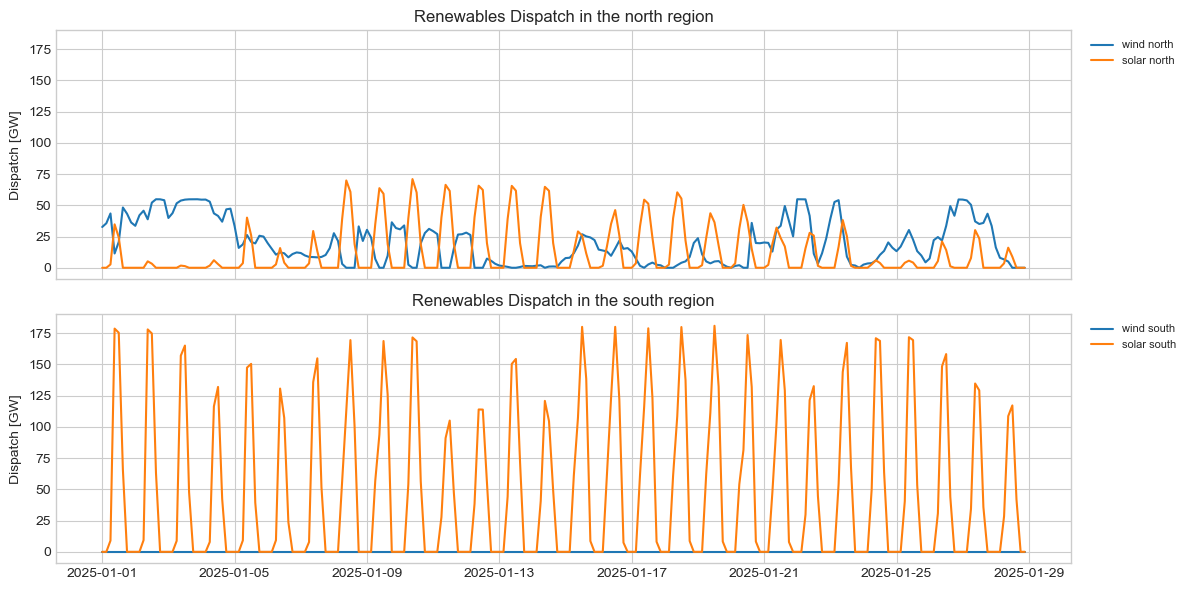

In [8]:
# TODO 1b (continued) — plot the dispatch for Scenario B
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)

ax[0].plot(mB_df.loc["north"].index, mB_df.loc["north"]["wind_dispatch"]/1000,  label="wind north", color="#1f77b4")
ax[0].plot(mB_df.loc["north"].index, mB_df.loc["north"]["pv_dispatch"]/1000,    label="solar north", color="#ff7f0e")
ax[0].set_ylabel("Dispatch [GW]")
ax[0].set_title("Renewables Dispatch in the north region")
ax[0].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

ax[1].plot(mB_df.loc["south"].index, mB_df.loc["south"]["wind_dispatch"]/1000,  label="wind south", color="#1f77b4")
ax[1].plot(mB_df.loc["south"].index, mB_df.loc["south"]["pv_dispatch"]/1000,    label="solar south", color="#ff7f0e")
ax[1].set_ylabel("Dispatch [GW]")
ax[1].set_title("Renewables Dispatch in the south region")
ax[1].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout()
plt.savefig("1b_wind_solar_dispatch.png", dpi=120, bbox_inches="tight")
plt.show()

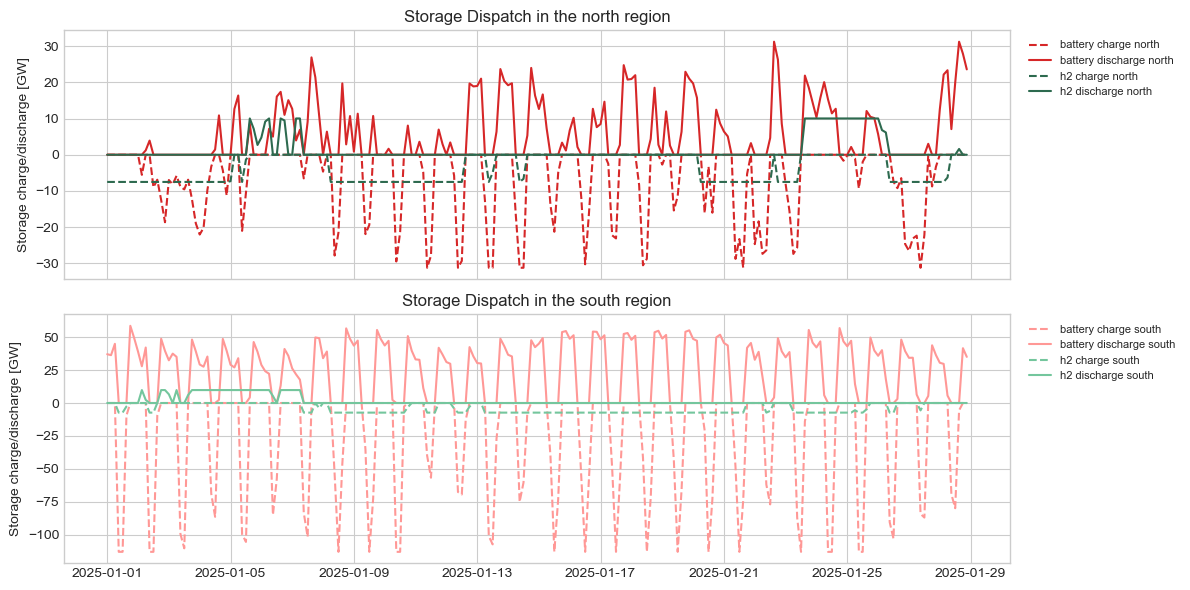

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax[0].plot(mB_df.loc["north"].index, mB_df.loc["north"]["battery_charge"]/1000*-1,    label="battery charge north",    color="#d62728", ls="--")
ax[0].plot(mB_df.loc["north"].index, mB_df.loc["north"]["battery_discharge"]/1000,    label="battery discharge north", color="#d62728")
ax[0].plot(mB_df.loc["north"].index, mB_df.loc["north"]["h2_charge"]/1000*-1,         label="h2 charge north",         color="#2d6a4f", ls="--")
ax[0].plot(mB_df.loc["north"].index, mB_df.loc["north"]["h2_discharge"]/1000,         label="h2 discharge north",      color="#2d6a4f")
ax[0].set_ylabel("Storage charge/discharge [GW]")
ax[0].set_title("Storage Dispatch in the north region")
ax[0].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

ax[1].plot(mB_df.loc["south"].index, mB_df.loc["south"]["battery_charge"]/1000*-1,   label="battery charge south",    color="#ff9896", ls="--")
ax[1].plot(mB_df.loc["south"].index, mB_df.loc["south"]["battery_discharge"]/1000,   label="battery discharge south", color="#ff9896")
ax[1].plot(mB_df.loc["south"].index, mB_df.loc["south"]["h2_charge"]/1000*-1,        label="h2 charge south",         color="#74c69d", ls="--")
ax[1].plot(mB_df.loc["south"].index, mB_df.loc["south"]["h2_discharge"]/1000,        label="h2 discharge south",      color="#74c69d")
ax[1].set_ylabel("Storage charge/discharge [GW]")
ax[1].set_title("Storage Dispatch in the south region")
ax[1].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout()
plt.savefig("1b_storage_dispatch.png", dpi=120, bbox_inches="tight")
plt.show()

In [10]:
#Explanation
print(
"It can be observed that wind and solar are combined only in the northern node, whereas the southern node instead uses a combination of solar power and storage.\n"
"This is due to several reasons.\n"
"In scenario B (no line), each node has to cover its own demand, so the dispatch follows the local resource.\n"
"Generation dispatch:\n"
"In the north, the supply is a mix of wind and solar.\n"
"Wind carries the base supply across day and night and dominates in winter, while solar adds generation during the daytime hours, so the dispatch stays relatively continuous.\n"
"In the south, no wind is built at all, so solar is the only source. Its dispatch is strongly diurnal: high peaks around midday and zero at night, with large swings between the seasons.\n"
"Storage dispatch:\n"
"Because the north already has a fairly balanced wind-solar mix, it needs less storage.\n"
"The south depends entirely on solar, which produces nothing at night, so a lot of energy has to be shifted from day to night.\n"
"That is why both the battery and the H2 charge/discharge power and storage capacity are clearly higher in the south.\n"
"Batteries handle the short day-night cycle, while H2 covers the longer, seasonal shifts.\n"
"Overall, this split is the solver's least-cost choice: it follows the local production potential (north = windiest node, south = sunniest node) together with the technology costs."
)

It can be observed that wind and solar are combined only in the northern node, whereas the southern node instead uses a combination of solar power and storage.
This is due to several reasons.
In scenario B (no line), each node has to cover its own demand, so the dispatch follows the local resource.
Generation dispatch:
In the north, the supply is a mix of wind and solar.
Wind carries the base supply across day and night and dominates in winter, while solar adds generation during the daytime hours, so the dispatch stays relatively continuous.
In the south, no wind is built at all, so solar is the only source. Its dispatch is strongly diurnal: high peaks around midday and zero at night, with large swings between the seasons.
Storage dispatch:
Because the north already has a fairly balanced wind-solar mix, it needs less storage.
The south depends entirely on solar, which produces nothing at night, so a lot of energy has to be shifted from day to night.
That is why both the battery and the

### Task 1c — Compare the two scenarios (1 pt)

**Compare the two scenarios.** How do the investments into **generation, storage, and transmission** change?

**Output:** show the investment costs in a table and plot the capacities.

In [11]:
# TODO 1c — solve Scenario A (line free); report TOTEX for A & B and the line built
mA = solve(True)

totex_B = mB.objective.value
totex_A = mA.objective.value
line_built = mA.solution["line_capacity"]

print(f"TOTEX Scenario B (no line): {round(totex_B,2)} EUR")
print(f"TOTEX Scenario A (line): {round(totex_A,2)} EUR")
print(f"Savings through Line inclusion: {round(totex_B - totex_A,2)} EUR")
print(f"Build Line Capacity: {line_built/1e3:,.2f} GW")

TOTEX Scenario B (no line): 3412846097.38 EUR
TOTEX Scenario A (line): 3056740408.5 EUR
Savings through Line inclusion: 356105688.88 EUR
Build Line Capacity: 14.06 GW


In [12]:
mA_df = mA.solution.to_dataframe()
mA_df

wind_capacity    pv_capacity  \
node  time                                                
north 2025-01-01 00:00:00   70570.793964   28635.756373   
      2025-01-01 03:00:00   70570.793964   28635.756373   
      2025-01-01 06:00:00   70570.793964   28635.756373   
      2025-01-01 09:00:00   70570.793964   28635.756373   
      2025-01-01 12:00:00   70570.793964   28635.756373   
...                                  ...            ...   
south 2025-01-28 09:00:00       0.000000  397244.628439   
      2025-01-28 12:00:00       0.000000  397244.628439   
      2025-01-28 15:00:00       0.000000  397244.628439   
      2025-01-28 18:00:00       0.000000  397244.628439   
      2025-01-28 21:00:00       0.000000  397244.628439   

                           electrolyser_capacity  fuel_cell_capacity  \
node  time                                                             
north 2025-01-01 00:00:00            2276.476577          4518.85180   
      2025-01-01 03:00:00            2276.476577          4518.85180   
      2025-01-01 06:00:00            2276.476577          4518.85180   
      2025-01-01 09:00:00            2276.476577          4518.85180   
      2025-01-01 12:00:00            2276.476577          4518.85180   
...                                          ...                 ...   
south 2025-01-28 09:00:00            3152.428111          4352.72087   
      2025-01-28 12:00:00            3152.428111          4352.72087   
      2025-01-28 15:00:00            3152.428111          4352.72087   
      2025-01-28 18:00:00            3152.428111          4352.72087   
      2025-01-28 21:00:00            3152.428111          4352.72087   

                           h2_storage_capacity  battery_inverter_capacity  \
node  time                                                                  
north 2025-01-01 00:00:00        657692.146828               16091.717939   
      2025-01-01 03:00:00        657692.146828               16091.717939   
      2025-01-01 06:00:00        657692.146828               16091.717939   
      2025-01-01 09:00:00        657692.146828               16091.717939   
      2025-01-01 12:00:00        657692.146828               16091.717939   
...                                        ...                        ...   
south 2025-01-28 09:00:00        831756.806544              110370.557296   
      2025-01-28 12:00:00        831756.806544              110370.557296   
      2025-01-28 15:00:00        831756.806544              110370.557296   
      2025-01-28 18:00:00        831756.806544              110370.557296   
      2025-01-28 21:00:00        831756.806544              110370.557296   

                           battery_storage_capacity  line_capacity  \
node  time                                                           
north 2025-01-01 00:00:00             322761.817902   14057.058638   
      2025-01-01 03:00:00             322761.817902   14057.058638   
      2025-01-01 06:00:00             322761.817902   14057.058638   
      2025-01-01 09:00:00             322761.817902   14057.058638   
      2025-01-01 12:00:00             322761.817902   14057.058638   
...                                             ...            ...   
south 2025-01-28 09:00:00             801498.034088   14057.058638   
      2025-01-28 12:00:00             801498.034088   14057.058638   
      2025-01-28 15:00:00             801498.034088   14057.058638   
      2025-01-28 18:00:00             801498.034088   14057.058638   
      2025-01-28 21:00:00             801498.034088   14057.058638   

                             pv_dispatch  wind_dispatch  h2_discharge  \
node  time                                                              
north 2025-01-01 00:00:00      -0.000000   41456.935214           0.0   
      2025-01-01 03:00:00      -0.000000   44434.535214           0.0   
      2025-01-01 06:00:00     735.652581   54215.982633           0.0   
      2025-01-01 09:00:00    9586.105803   1

,B (no line) [MioEUR/a],A (line) [MioEUR/a],Δ A−B [MioEUR/a]
Wind,6857.84,8385.20,1527.36
Solar,19105.33,15713.87,-3391.46
H2_electrolyser,2343.24,858.77,-1484.46
H2_fuel_cell,4078.24,1823.84,-2254.40
H2_store,359.46,167.43,-192.04
Battery_inverter,1751.40,1535.75,-215.65
Battery_store,9714.26,9085.28,-628.97
Line,0.00,1953.91,1953.91


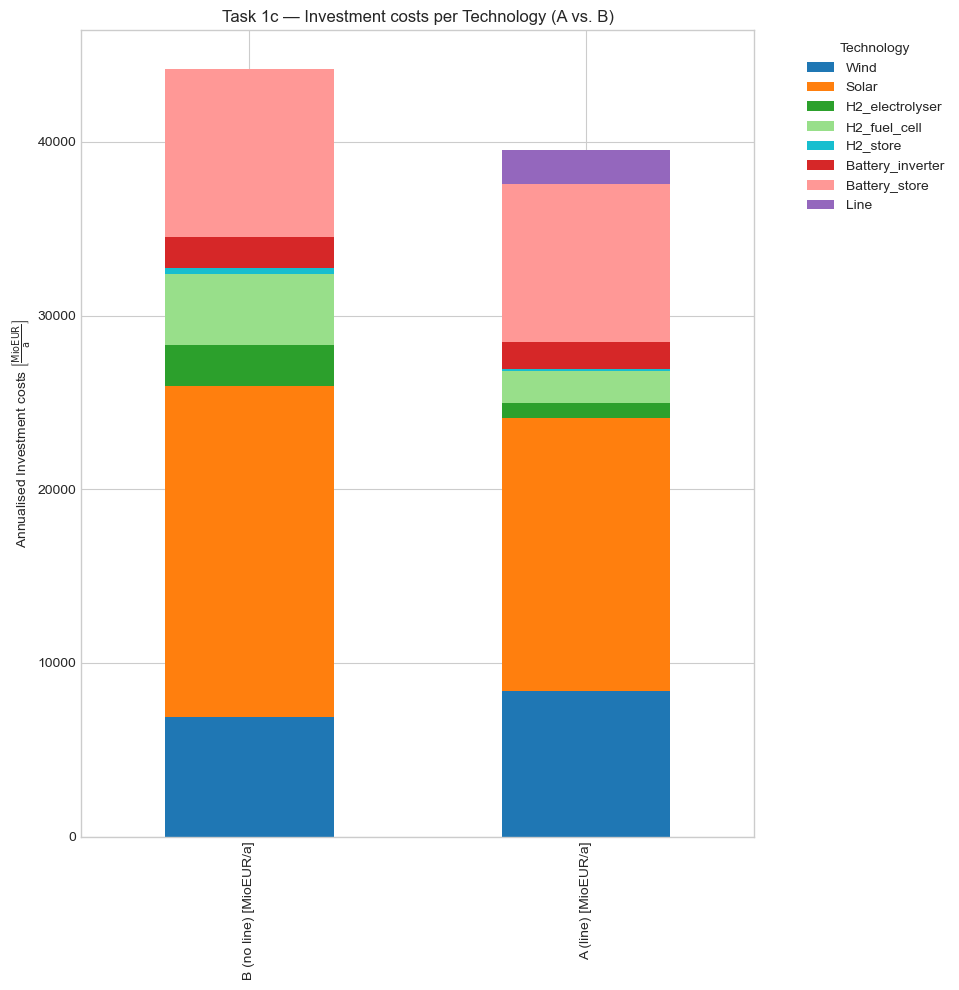

In [13]:
# TODO 1c (continued) — annualised investment cost per technology (A vs B) + stacked bar
#defining a dictionary to map the tech name to the capacity outcome for the fuctiion
tech_to_var = {
    "Wind":             "wind_capacity",
    "Solar":            "pv_capacity",
    "H2_electrolyser":  "electrolyser_capacity",
    "H2_fuel_cell":     "fuel_cell_capacity",
    "H2_store":         "h2_storage_capacity",
    "Battery_inverter": "battery_inverter_capacity",
    "Battery_store":    "battery_storage_capacity",
    "Line":             "line_capacity",
}

def total_capacity(m):
    sol = m.solution
    return pd.Series({t: float(sol[v].sum()) for t, v in tech_to_var.items()})

capB, capA = total_capacity(mB), total_capacity(mA)

#anualised investement costs
techs = tech_to_var.keys()
inv_table = pd.DataFrame({
    "B (no line) [MioEUR/a]": c_inv.loc[techs].values * capB.values / 1e6,
    "A (line) [MioEUR/a]":    c_inv.loc[techs].values * capA.values / 1e6,
}, index=techs)
inv_table["Δ A−B [MioEUR/a]"] = inv_table["A (line) [MioEUR/a]"] - inv_table["B (no line) [MioEUR/a]"]
display(inv_table.round(2))
tech_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#98df8a", "#17becf", "#d62728", "#ff9896", "#9467bd"]

#stacked bar chart
ax = inv_table.drop(columns="Δ A−B [MioEUR/a]").T.plot(kind="bar", stacked=True, figsize=(10,10), color=tech_colors)
ax.set_ylabel(r"Annualised Investment costs $\left[\frac{\rm MioEUR}{\rm a}\right]$")
ax.set_title("Task 1c — Investment costs per Technology (A vs. B)")
ax.legend(title="Technology", loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.savefig("fig_1c_invcost.png", dpi=120, bbox_inches="tight")
plt.show()

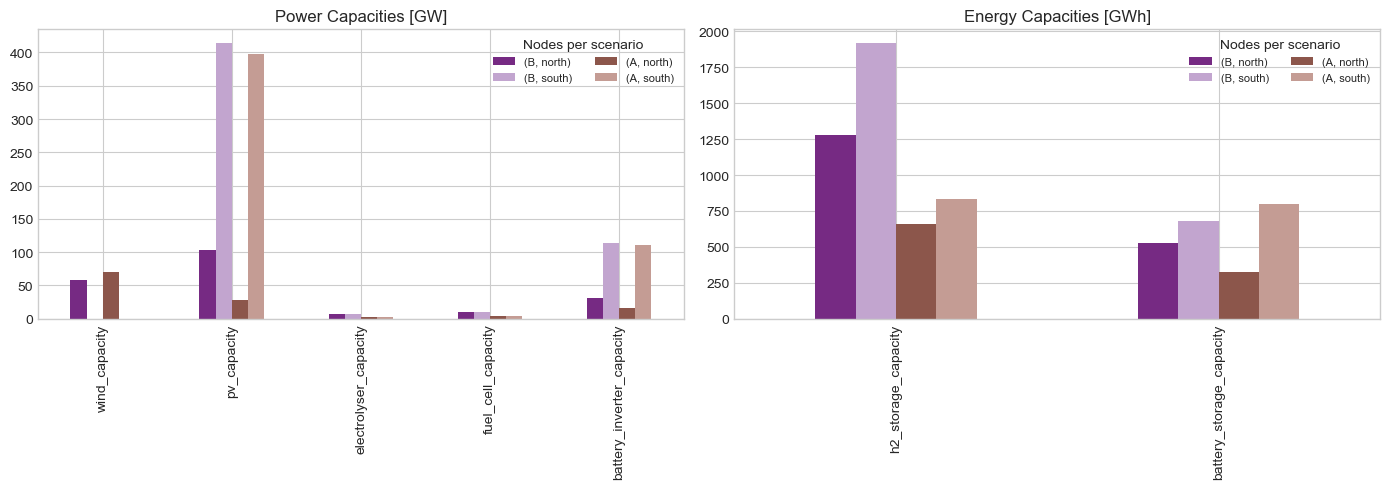

In [35]:
# TODO 1c (continued) — capacity comparison plots per node (power [GW] vs energy [GWh])
#plotting the capacities for each technology per node
power_cols  = ["wind_capacity","pv_capacity","electrolyser_capacity",
               "fuel_cell_capacity","battery_inverter_capacity"]
energy_cols = ["h2_storage_capacity","battery_storage_capacity"]

node_scen_colors = {
    ("B", "north"): "#762a83",
    ("B", "south"): "#c2a5cf",
    ("A", "north"): "#8c564b",
    ("A", "south"): "#c49c94",
}

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

power = pd.concat({"B": mB_df[power_cols].groupby("node").first() / 1e3,
                   "A": mA_df[power_cols].groupby("node").first() / 1e3}, names=["scenario"])
power_colors = [node_scen_colors[idx] for idx in power.index]
power.T.plot(kind="bar", ax=ax[0], color=power_colors)
ax[0].set_title("Power Capacities [GW]")
ax[0].legend(title="Nodes per scenario", fontsize=8, ncol=2)

energy = pd.concat({"B": mB_df[energy_cols].groupby("node").first() / 1e3,
                    "A": mA_df[energy_cols].groupby("node").first() / 1e3}, names=["scenario"])
energy_colors = [node_scen_colors[idx] for idx in energy.index]
energy.T.plot(kind="bar", ax=ax[1], color=energy_colors)
ax[1].set_title("Energy Capacities [GWh]")
ax[1].legend(title="Nodes per scenario", fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig("fig_1c_capacities.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
#Explanation
print(
"The total investment costs shrink when line capacity is built (TOTEX falls from ~3.41 to ~3.06 billion EUR).\n"
"With the line, the regions no longer have to cover their demand on their own, so they can specialise.\n"
"Generation:\n"
"The north expands wind and strongly cuts its solar, turning into a cheap wind exporter, while the south stays solar-based.\n"
"Wind in the north is favourable because its good resource potential combined with the costs helps to reduce total costs.\n"
"The south keeps its strong solar potential and only needs to reduce its storage and a little of its production capacity to meet demand.\n"
"Storage:\n"
"Because excess energy can be transferred between regions instead of being stored locally, less storage is needed overall.\n"
"This is mostly visible in the H2 storage (it drops by roughly half) and in the northern battery, while the southern battery even grows slightly.\n"
"Transmission:\n"
"Line capacity is built to carry the energy and to smooth the supply across seasonal and day/night differences between the windy north and the sunny south."
)

The total investment costs shrink when line capacity is built (TOTEX falls from ~3.41 to ~3.06 billion EUR).
With the line, the regions no longer have to cover their demand on their own, so they can specialise.
Generation:
The north expands wind and strongly cuts its solar, turning into a cheap wind exporter, while the south stays solar-based.
Wind in the north is favourable because its good resource potential combined with the costs helps to reduce total costs.
The south keeps its strong solar potential and only needs to reduce its storage and a little of its production capacity to meet demand.
Storage:
Because excess energy can be transferred between regions instead of being stored locally, less storage is needed overall.
This is mostly visible in the H2 storage (it drops by roughly half) and in the northern battery, while the southern battery even grows slightly.
Transmission:
Line capacity is built to carry the energy and to smooth the supply across seasonal and day/night differenc

### Task 1d — Curtailment (0.5 pt)

How does **curtailment** by technology and region change from the **no-line case** to the **transmission case** and why?

**Output:** quantify and explain.

In [16]:
# TODO 1d — compute and plot vRES curtailment by technology for both scenarios
def Curtailment(m):
    solution = m.solution.to_dataframe()
    
    wind_potential_north = solution.loc["north"]["wind_capacity"] * cf["wind_north"] 
    wind_potential_south = solution.loc["south"]["wind_capacity"] * cf["wind_south"] 
    pv_potential_north = solution.loc["north"]["pv_capacity"] * cf["solar_north"] 
    pv_potential_south = solution.loc["south"]["pv_capacity"] * cf["solar_south"] 

    wind_dispatch_north = solution.loc["north"]["wind_dispatch"]
    wind_dispatch_south = solution.loc["south"]["wind_dispatch"]
    pv_dispatch_north = solution.loc["north"]["pv_dispatch"]
    pv_dispatch_south = solution.loc["south"]["pv_dispatch"]

    curtailment_wind_north = wind_potential_north - wind_dispatch_north
    curtailment_wind_south = wind_potential_south - wind_dispatch_south
    curtailment_pv_north = pv_potential_north - pv_dispatch_north
    curtailment_pv_south = pv_potential_south - pv_dispatch_south

    curtailment = pd.DataFrame({
        "wind_north" : curtailment_wind_north,
        "wind_south" : curtailment_wind_south,
        "pv_north"   : curtailment_pv_north,
        "pv_south"   : curtailment_pv_south
    })

    return curtailment

curtailment_A = Curtailment(mA)
curtailment_B = Curtailment(mB)

In [17]:
curtailment_A

,wind_north,wind_south,pv_north,pv_south
time,,,,
2025-01-01 00:00:00,25433.591844,0.0,0.0,0.000000
2025-01-01 03:00:00,22598.544848,0.0,0.0,0.000000
2025-01-01 06:00:00,12817.803137,0.0,0.0,0.000000
2025-01-01 09:00:00,49366.382452,0.0,0.0,6030.598186
2025-01-01 12:00:00,47902.171646,0.0,0.0,35621.199712
...,...,...,...,...
2025-01-28 09:00:00,0.000000,0.0,0.0,0.000000
2025-01-28 12:00:00,0.000000,0.0,0.0,0.000000
2025-01-28 15:00:00,0.000000,0.0,0.0,0.000000


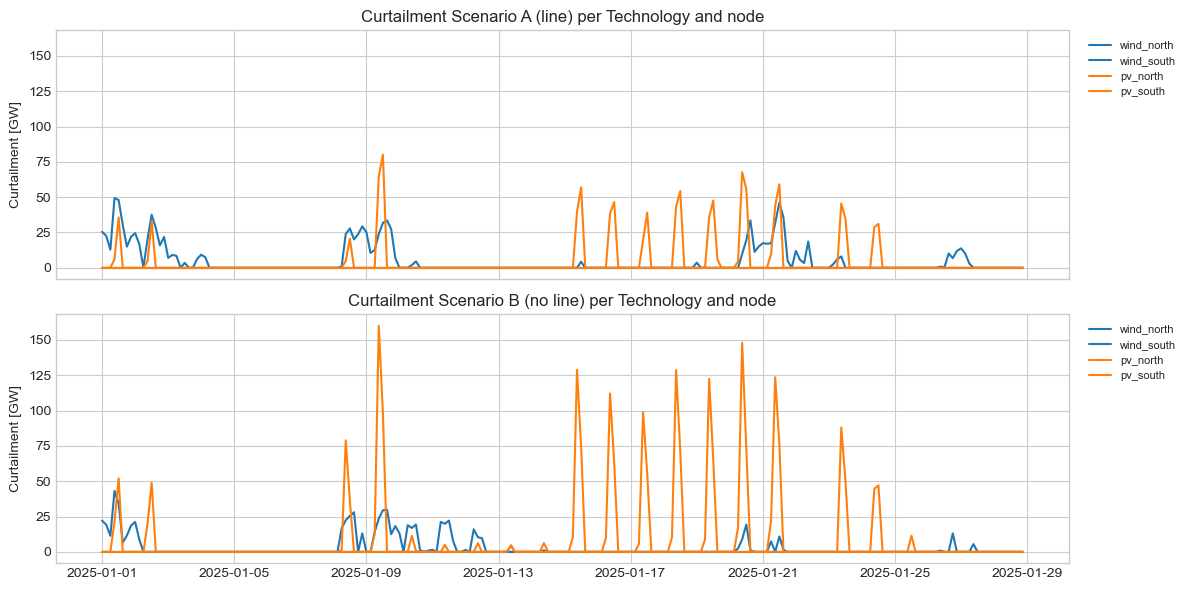

,B,A
wind_north,2044.174614,3375.860486
wind_south,0.000000,0.000000
pv_north,65.646549,0.000000
pv_south,6641.719841,3168.801646


In [18]:
col_colors = {"wind_north": "#1f77b4", "wind_south": "#1f77b4",
              "pv_north":   "#ff7f0e", "pv_south":   "#ff7f0e"}

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)
for col in curtailment_A.columns:
    ax[0].plot(curtailment_A[col]/1e3, label=col, color=col_colors[col])
ax[0].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax[0].set_title("Curtailment Scenario A (line) per Technology and node")
ax[0].set_ylabel("Curtailment [GW]")

for col in curtailment_B.columns:
    ax[1].plot(curtailment_B[col]/1e3, label=col, color=col_colors[col])
ax[1].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax[1].set_title("Curtailment Scenario B (no line) per Technology and node")
ax[1].set_ylabel("Curtailment [GW]")

plt.tight_layout()
plt.savefig("fig_1d_curtailment.png", dpi=120, bbox_inches="tight")
plt.show()

totals = pd.DataFrame({"B": (curtailment_B * DT).sum() / 1e3,
                       "A": (curtailment_A * DT).sum() / 1e3})
totals

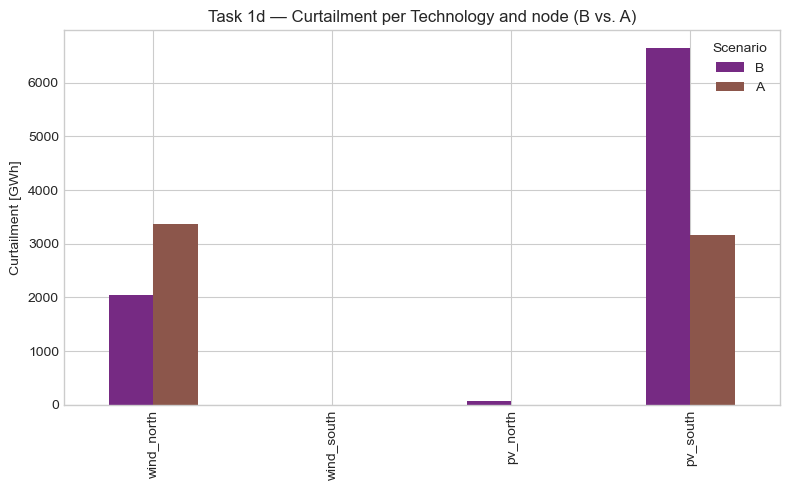

In [31]:
ax = totals.plot(kind="bar", figsize=(8, 5), color=["#762a83", "#8c564b"])
ax.set_ylabel("Curtailment [GWh]")
ax.set_title("Task 1d — Curtailment per Technology and node (B vs. A)")
ax.legend(title="Scenario")
plt.tight_layout()
plt.savefig("fig_1d_curtailment_bar.png", dpi=120, bbox_inches="tight")
plt.show()

In [20]:
#Explanation
print(
"Total curtailment falls when the line is built, but it does not fall everywhere.\n"
"South PV: Curtailment drops strongly.\n"
"In the no-line case, the south has a large midday solar surplus that it cannot use or store, so it has to be spilled.\n"
"With the line, this surplus can be exported to the north instead of being curtailed.\n"
"North wind: Curtailment actually increases.\n"
"With the line, the north overbuilds cheap wind to export it.\n"
"During high-wind hours, the line and storage cannot always absorb all of it, so a larger share of the wind potential is spilled.\n"
"North PV: It drops to zero because the north barely builds any solar anymore in the line scenario.\n"
"So the line reduces overall curtailment by letting the regions share their surplus, but it shifts the remaining curtailment towards the technology that is deliberately overbuilt for export (northern wind)."
)

Total curtailment falls when the line is built, but it does not fall everywhere.
South PV: Curtailment drops strongly.
In the no-line case, the south has a large midday solar surplus that it cannot use or store, so it has to be spilled.
With the line, this surplus can be exported to the north instead of being curtailed.
North wind: Curtailment actually increases.
With the line, the north overbuilds cheap wind to export it.
During high-wind hours, the line and storage cannot always absorb all of it, so a larger share of the wind potential is spilled.
North PV: It drops to zero because the north barely builds any solar anymore in the line scenario.
So the line reduces overall curtailment by letting the regions share their surplus, but it shifts the remaining curtailment towards the technology that is deliberately overbuilt for export (northern wind).


### Task 1e — Residual load curves (0.5 pt)

How do the **residual load curves** change across the two scenarios?

**Output:** plot the residual load curves and explain the differences.

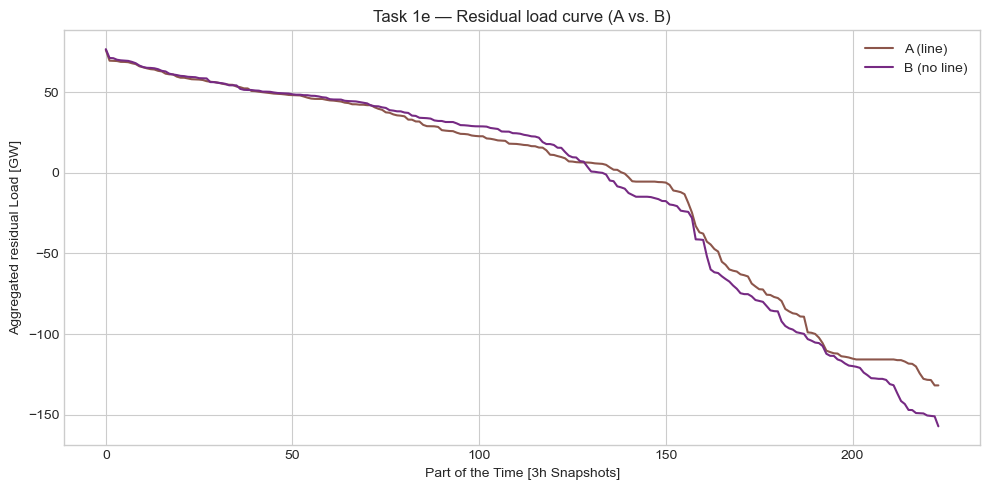

In [21]:
# TODO 1e — compute and plot aggregate residual-load duration curves for both scenarios
def residual_load(m):
    solution = m.solution
    dis = solution["wind_dispatch"] + solution["pv_dispatch"]
    residual = (demand_da - dis).sum("node")
    return residual.to_series().sort_values(ascending=False).reset_index(drop=True)

residualA, residualB = residual_load(mA), residual_load(mB)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(residualB))
ax.plot(x, residualA.values/1e3, label="A (line)",    color="#8c564b")
ax.plot(x, residualB.values/1e3, label="B (no line)", color="#762a83")
ax.set_xlabel("Part of the Time [3h Snapshots]")
ax.set_ylabel("Aggregated residual Load [GW]")
ax.set_title("Task 1e — Residual load curve (A vs. B)")
ax.legend()
plt.tight_layout()
plt.savefig("fig_1e_rldc.png", dpi=120, bbox_inches="tight")
plt.show()

In [22]:
#Explanation
print(
"The peak of the curve is almost identical in both scenarios.\n"
"This corresponds to the system-wide situation in which neither wind nor PV generation is available.\n"
"When both regions simultaneously experience low wind and solar availability, the transmission line cannot provide additional support, since no surplus energy is available for spatial balancing.\n"
"Consequently, storage must cover the demand.\n"
"The main difference appears at the negative (surplus) end of the curve: with the transmission line, the curve is significantly flatter.\n"
"The line enables spatial balancing of non-simultaneous surpluses between regions (northern wind and southern solar), thereby reducing the amount of energy that needs to be shifted through storage.\n"
"This is consistent with the results in Sections 1c and 1d: with transmission, the system relies less on storage (resulting in lower hydrogen capacities) and experiences less curtailment, as spatial exchange partially substitutes temporal storage."
)

The peak of the curve is almost identical in both scenarios.
This corresponds to the system-wide situation in which neither wind nor PV generation is available.
When both regions simultaneously experience low wind and solar availability, the transmission line cannot provide additional support, since no surplus energy is available for spatial balancing.
Consequently, storage must cover the demand.
The main difference appears at the negative (surplus) end of the curve: with the transmission line, the curve is significantly flatter.
The line enables spatial balancing of non-simultaneous surpluses between regions (northern wind and southern solar), thereby reducing the amount of energy that needs to be shifted through storage.
This is consistent with the results in Sections 1c and 1d: with transmission, the system relies less on storage (resulting in lower hydrogen capacities) and experiences less curtailment, as spatial exchange partially substitutes temporal storage.


## Task 2 — Interpret the dual solution: shadow prices (2 pts)

No additional plots required unless stated. The **nodal price** is the balance-constraint dual
divided by `DT` (EUR/MWh). Investment pro-rating ensures these are realistic energy prices.

### Task 2a — Shadow prices of the nodal energy balances (0.5 pt)

For each scenario, extract the **shadow variable of the nodal energy balances** and weight it by the nodal demand in the north and south, respectively. What do they represent? Why are they different in the two regions? When do you observe the highest values and why?

,A (line) [EUR/MWh],B (no line) [EUR/MWh]
node,,
north,65.35,74.90
south,58.63,64.22


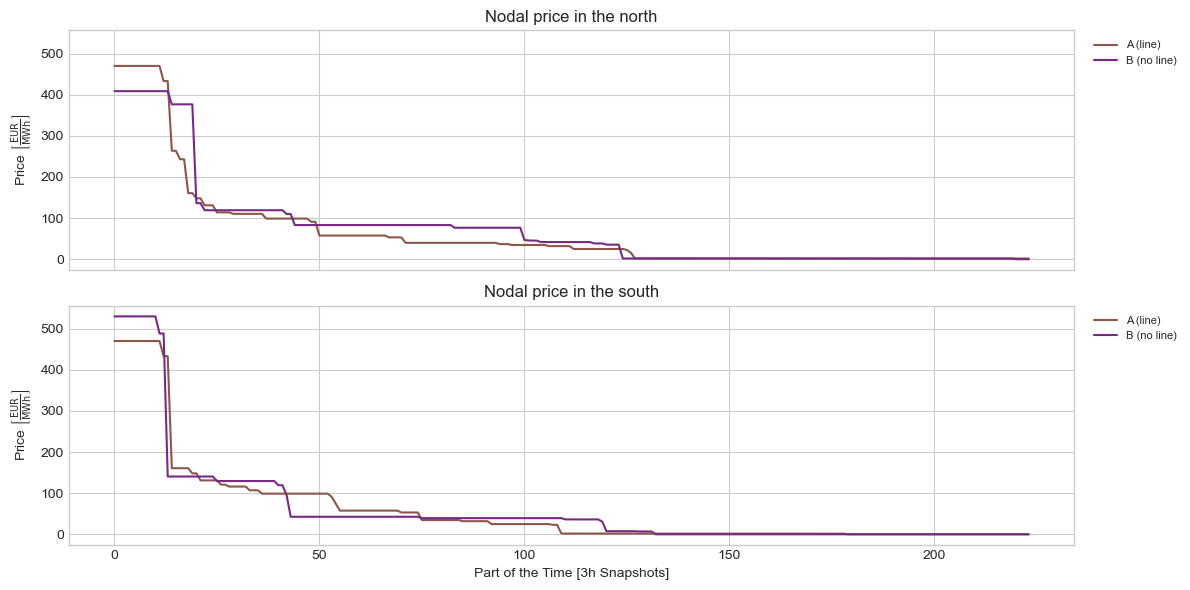

In [23]:
# TODO 2a — extract nodal balance duals, compute demand-weighted prices,
#            and plot nodal price duration curves for A and B
priceA = mA.constraints["Power_balance_north_south"].dual / DT
priceB = mB.constraints["Power_balance_north_south"].dual / DT

weightedA = (priceA * demand_da).sum("time") / demand_da.sum("time")
weightedB = (priceB * demand_da).sum("time") / demand_da.sum("time")

summary = pd.DataFrame({
    "A (line) [EUR/MWh]":    weightedA.to_series(),
    "B (no line) [EUR/MWh]": weightedB.to_series(),
})
display(summary.round(2))

priceA_s = priceA.to_series()
priceB_s = priceB.to_series()
x = np.arange(len(priceA_s.loc["north"]))

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, sharey=True)

ax[0].plot(x, np.sort(priceA_s.loc["north"])[::-1], label="A (line)",    color="#8c564b")
ax[0].plot(x, np.sort(priceB_s.loc["north"])[::-1], label="B (no line)", color="#762a83")
ax[0].set_title("Nodal price in the north")
ax[0].set_ylabel(r"Price $\left[\frac{\rm EUR}{\rm MWh}\right]$")
ax[0].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

ax[1].plot(x, np.sort(priceA_s.loc["south"])[::-1], label="A (line)",    color="#8c564b")
ax[1].plot(x, np.sort(priceB_s.loc["south"])[::-1], label="B (no line)", color="#762a83")
ax[1].set_title("Nodal price in the south")
ax[1].set_ylabel(r"Price $\left[\frac{\rm EUR}{\rm MWh}\right]$")
ax[1].set_xlabel("Part of the Time [3h Snapshots]")
ax[1].legend(ncol=1, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout()
plt.savefig("fig_2a_prices.png", dpi=120, bbox_inches="tight")
plt.show()

In [24]:
#Explanation
print(
"The price duration curve shows the nodal price for each share of the time, sorted from high to low.\n"
"For example, in roughly the most expensive fifth of the hours the price is above 100 EUR/MWh.\n"
"The dual variable of the nodal energy balance represents the marginal cost of supplying one additional MWh at the respective node, i.e. the local electricity price (EUR/MWh).\n"
"Weighting it by the nodal demand gives the average price paid by consumers in that region over the modelled period.\n"
"In scenario B, prices differ because each node forms its own price independently. The south has large near-zero-cost midday solar surpluses that pull its average down, while the north's wind-dominated mix has almost no surplus hours, so wind's variable cost (1.62 EUR/MWh) sets the price most of the time, resulting in a higher average. In scenario A, the line couples the two prices during hours of full capacity, flattening both duration curves and bringing regional averages closer together.\n"
"The highest price values are observed during dark-lull hours when neither wind nor solar generation is available.\n"
"In these scarcity periods the only remaining dispatchable source is the H2 fuel cell, whose dispatch sets the marginal price. In scenario B the extreme price peaks occur in the south, as a solar-only region it is most exposed when there is no sunshine.\n"
"In scenario A the transmission line couples both nodes during scarcity, so both regions reach the same peak price simultaneously (the southern extreme is lowered and the northern peak is raised until they converge)."
)

The price duration curve shows the nodal price for each share of the time, sorted from high to low.
For example, in roughly the most expensive fifth of the hours the price is above 100 EUR/MWh.
The dual variable of the nodal energy balance represents the marginal cost of supplying one additional MWh at the respective node, i.e. the local electricity price (EUR/MWh).
Weighting it by the nodal demand gives the average price paid by consumers in that region over the modelled period.
In scenario B, prices differ because each node forms its own price independently. The south has large near-zero-cost midday solar surpluses that pull its average down, while the north's wind-dominated mix has almost no surplus hours, so wind's variable cost (1.62 EUR/MWh) sets the price most of the time, resulting in a higher average. In scenario A, the line couples the two prices during hours of full capacity, flattening both duration curves and bringing regional averages closer together.
The highest price va

### Task 2b — Consumer benefit from transmission (0.5 pt)

In the transmission scenario, **consumers of which region** benefit more from the transmission line: the north, the south, or both equally? Briefly explain.

,A (line) [EUR/MWh],B (no line) [EUR/MWh],change A-B
node,,,
north,65.35,74.90,-9.55
south,58.63,64.22,-5.59


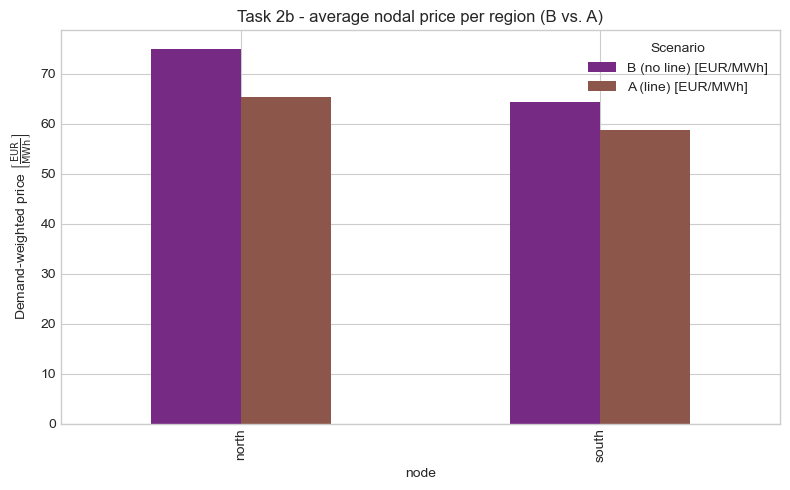

In [25]:
# TODO 2b — compute demand-weighted average nodal prices for both scenarios
#            and plot the comparison
summary["change A-B"] = summary["A (line) [EUR/MWh]"] - summary["B (no line) [EUR/MWh]"]
display(summary.round(2))

ax = summary[["B (no line) [EUR/MWh]", "A (line) [EUR/MWh]"]].plot(kind="bar", figsize=(8, 5), color=["#762a83", "#8c564b"])
ax.set_ylabel(r"Demand-weighted price $\left[\frac{\rm EUR}{\rm MWh}\right]$")
ax.set_title("Task 2b - average nodal price per region (B vs. A)")
ax.legend(title="Scenario")
plt.tight_layout()
plt.savefig("fig_2b_prices.png", dpi=120, bbox_inches="tight")
plt.show()

In [26]:
#Explanation
print(
"Consumers in the north benefit more from the transmission line, although both regions gain.\n"
"Northern consumers benefit more. In scenario B the north had the higher average price due to its tight wind-solar mix with almost no zero-price hours. The line gives the north access to cheap southern solar surplus, avoiding additional PV and storage investment and producing a larger absolute price reduction. The south benefits too, as it can export surplus instead of curtailing it and needs less storage, but its price reduction is smaller.\n"
"The line thus balances the two nodal prices and reduces them in both regions, but to a greater extent in the north."
)


Consumers in the north benefit more from the transmission line, although both regions gain.
Northern consumers benefit more. In scenario B the north had the higher average price due to its tight wind-solar mix with almost no zero-price hours. The line gives the north access to cheap southern solar surplus, avoiding additional PV and storage investment and producing a larger absolute price reduction. The south benefits too, as it can export surplus instead of curtailing it and needs less storage, but its price reduction is smaller.
The line thus balances the two nodal prices and reduces them in both regions, but to a greater extent in the north.


### Task 2c — Shadow price of the line-capacity constraint (0.5 pt)

Extract the **shadow price of the line-capacity constraint** in the transmission scenario. What does it represent? In the scenario where the transmission capacity is zero, you can also extract the dual variable. Comparing the two, what does it say about the **value of interconnection**?

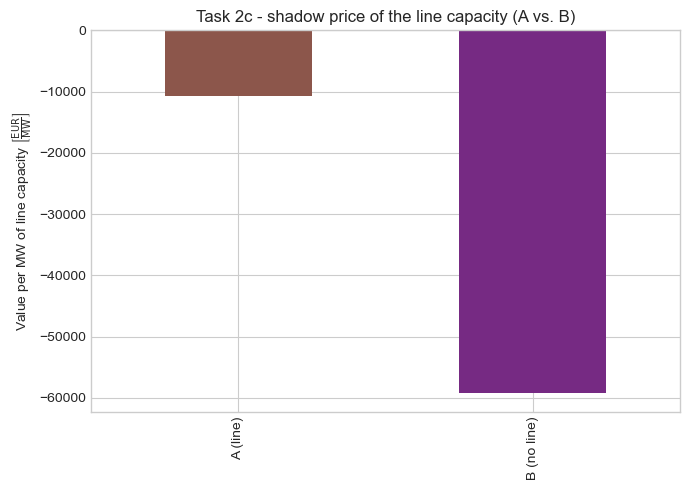

In [27]:
# TODO 2c — extract the shadow price of the line-capacity constraint
#            for both scenarios and plot the comparison
line_value_A = (mA.constraints["upper_transmission"].dual
              + mA.constraints["lower_transmission"].dual).sum().item()
line_value_B = (mB.constraints["no_line"].dual).sum().item()

compare = pd.Series({
    "A (line)":    line_value_A,
    "B (no line)": line_value_B,
})

ax = compare.plot(kind="bar", figsize=(7, 5), color=["#8c564b", "#762a83"])
ax.set_ylabel(r"Value per MW of line capacity $\left[\frac{\rm EUR}{\rm MW}\right]$")
ax.set_title("Task 2c - shadow price of the line capacity (A vs. B)")
plt.tight_layout()
plt.savefig("fig_2c_line.png", dpi=120, bbox_inches="tight")
plt.show()

In [28]:
#Explanation
print(
"The shadow price represents the congestion rent: how much the total system cost would drop if the line could carry one more MW.\n"
"It corresponds to the price difference between north and south in the hours when the line is operating at its capacity limit.\n"
"In scenario A (line), the shadow price is small (about -11 kEUR/MW).\n"
"Since the model is free to optimise the line capacity, it expands the line until the marginal benefit of one additional MW equals its annualised investment cost, so the residual marginal value is close to zero by construction.\n"
"In scenario B (no line), the line capacity is forced to zero.\n"
"The no-line constraint reflects the value of the very first MW of interconnection (about -59 kEUR/MW).\n"
"This value is roughly 5.6 times larger than the marginal value in scenario A, illustrating strongly decreasing returns to interconnection.\n"
"Interconnection is highly valuable, but with clearly decreasing value.\n"
"The first connections yield the greatest cost savings and additional capacity is built only as long as its marginal benefit exceeds its marginal cost."
)

The shadow price represents the congestion rent: how much the total system cost would drop if the line could carry one more MW.
It corresponds to the price difference between north and south in the hours when the line is operating at its capacity limit.
In scenario A (line), the shadow price is small (about -11 kEUR/MW).
Since the model is free to optimise the line capacity, it expands the line until the marginal benefit of one additional MW equals its annualised investment cost, so the residual marginal value is close to zero by construction.
In scenario B (no line), the line capacity is forced to zero.
The no-line constraint reflects the value of the very first MW of interconnection (about -59 kEUR/MW).
This value is roughly 5.6 times larger than the marginal value in scenario A, illustrating strongly decreasing returns to interconnection.
Interconnection is highly valuable, but with clearly decreasing value.
The first connections yield the greatest cost savings and additional capaci

### Task 2d — Advantages and disadvantages of heavy interconnection (0.5 pt)

Which advantages and disadvantages of heavy reliance on **cross-regional interconnection** does this stylised model *not* capture? No calculation needed.

In [29]:
print(
"The model captures the cost minimising value of interconnection under idealised conditions, but neglects several important real world effects.\n"
"Disadvantages not captured:\n"
"Highly interconnected systems are susceptible to cascade failures and systemic risk not representable in a lossless single-line model. Cross-border operation requires regulatory coordination and is exposed to political risk such as unilateral export restrictions. Large transmission projects also face public acceptance barriers that can delay or prevent construction.\n"
"Advantages not captured:\n"
"Beyond direct cost savings, interconnection improves system security by enabling imports during local shortfalls, reduces local market power, and promotes price convergence. The two-node topology also ignores meshed grid benefits such as N-1 security and reactive power support, so the model understates the true social value of interconnection.\n"
"Overall, the model provides a partial view of the true social value of interconnection, since it omits both the non-market benefits and the systemic risks that become relevant at high integration levels."
)

The model captures the cost minimising value of interconnection under idealised conditions, but neglects several important real world effects.
Disadvantages not captured:
Highly interconnected systems are susceptible to cascade failures and systemic risk not representable in a lossless single-line model. Cross-border operation requires regulatory coordination and is exposed to political risk such as unilateral export restrictions. Large transmission projects also face public acceptance barriers that can delay or prevent construction.
Advantages not captured:
Beyond direct cost savings, interconnection improves system security by enabling imports during local shortfalls, reduces local market power, and promotes price convergence. The two-node topology also ignores meshed grid benefits such as N-1 security and reactive power support, so the model understates the true social value of interconnection.
Overall, the model provides a partial view of the true social value of interconnection, s